<a href="https://colab.research.google.com/github/edarsllnn/amazon-satis-analizi/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Veri başarıyla yüklendi!


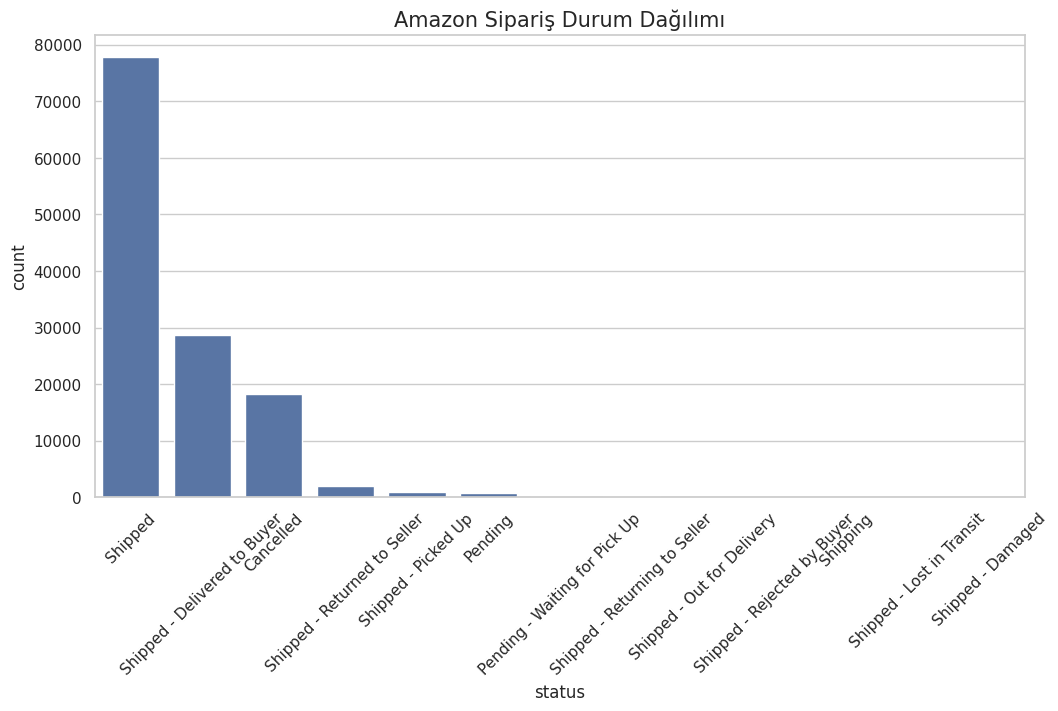

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dosya adı
df = pd.read_csv('amazon_data.csv.csv')
print("Veri başarıyla yüklendi!")

# Grafik Ayarları
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Sipariş Durum Grafiği
sns.countplot(data=df, x='status', order=df['status'].value_counts().index)
plt.title('Amazon Sipariş Durum Dağılımı', fontsize=15)
plt.xticks(rotation=45)
plt.show()

/tmp/ipython-input-202/2964193881.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Category'].isin(top_categories)], x='Category', order=top_categories, palette='viridis')


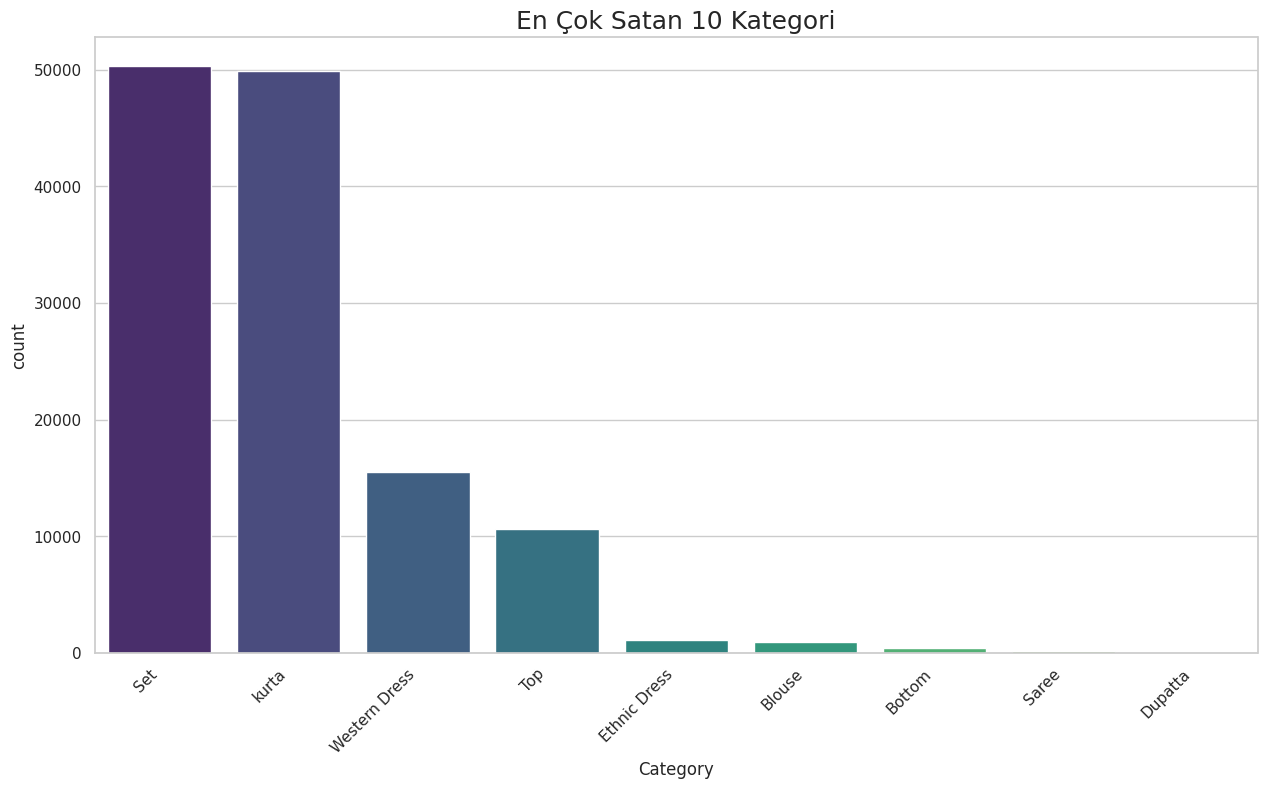

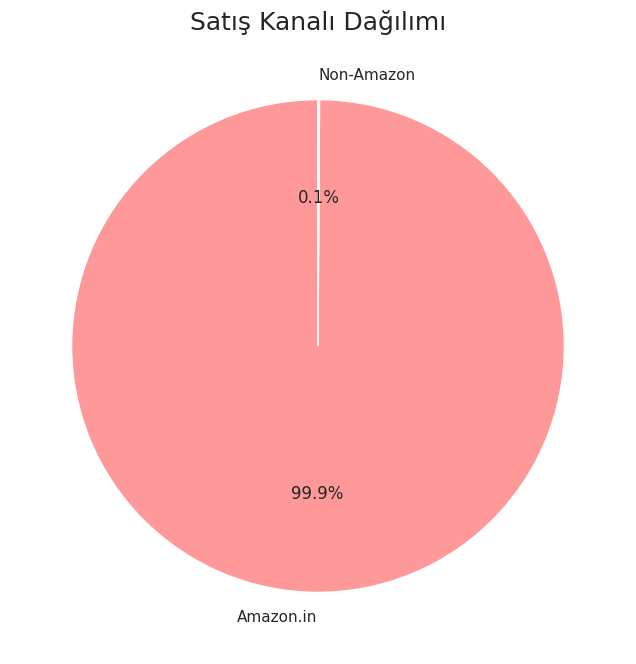

/tmp/ipython-input-202/2964193881.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Fulfilment', palette='pastel')


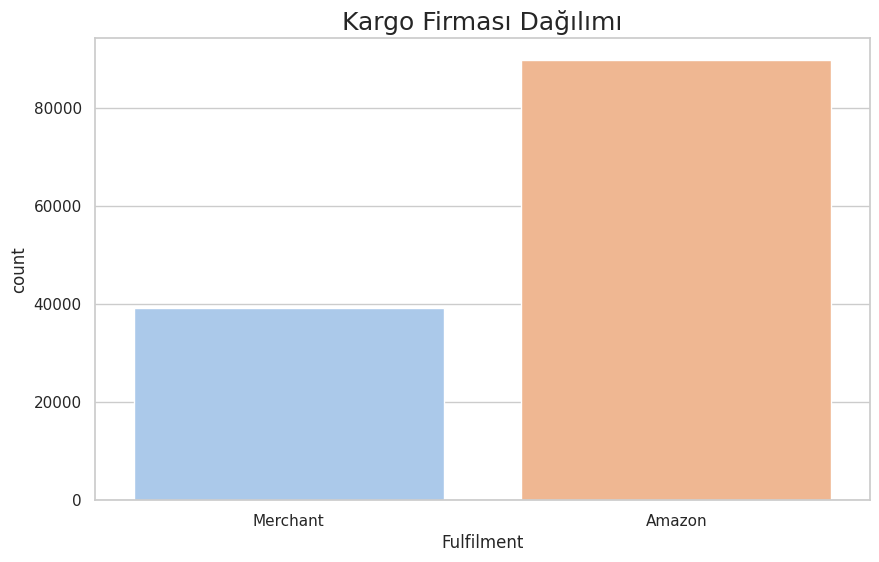

In [23]:
# 1. En Çok Satan 10 Kategori
plt.figure(figsize=(15, 8))
top_categories = df['Category'].value_counts().nlargest(10).index
sns.countplot(data=df[df['Category'].isin(top_categories)], x='Category', order=top_categories, palette='viridis')
plt.title('En Çok Satan 10 Kategori', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.show()

# 2. Satış Kanalı Dağılımı (Pasta Grafiği)
plt.figure(figsize=(8, 8))
channel_counts = df['Sales_channel'].value_counts()
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Satış Kanalı Dağılımı', fontsize=18)
plt.show()

# 3. Kargo Firması Dağılımı
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Fulfilment', palette='pastel')
plt.title('Kargo Firması Dağılımı', fontsize=18)
plt.show()

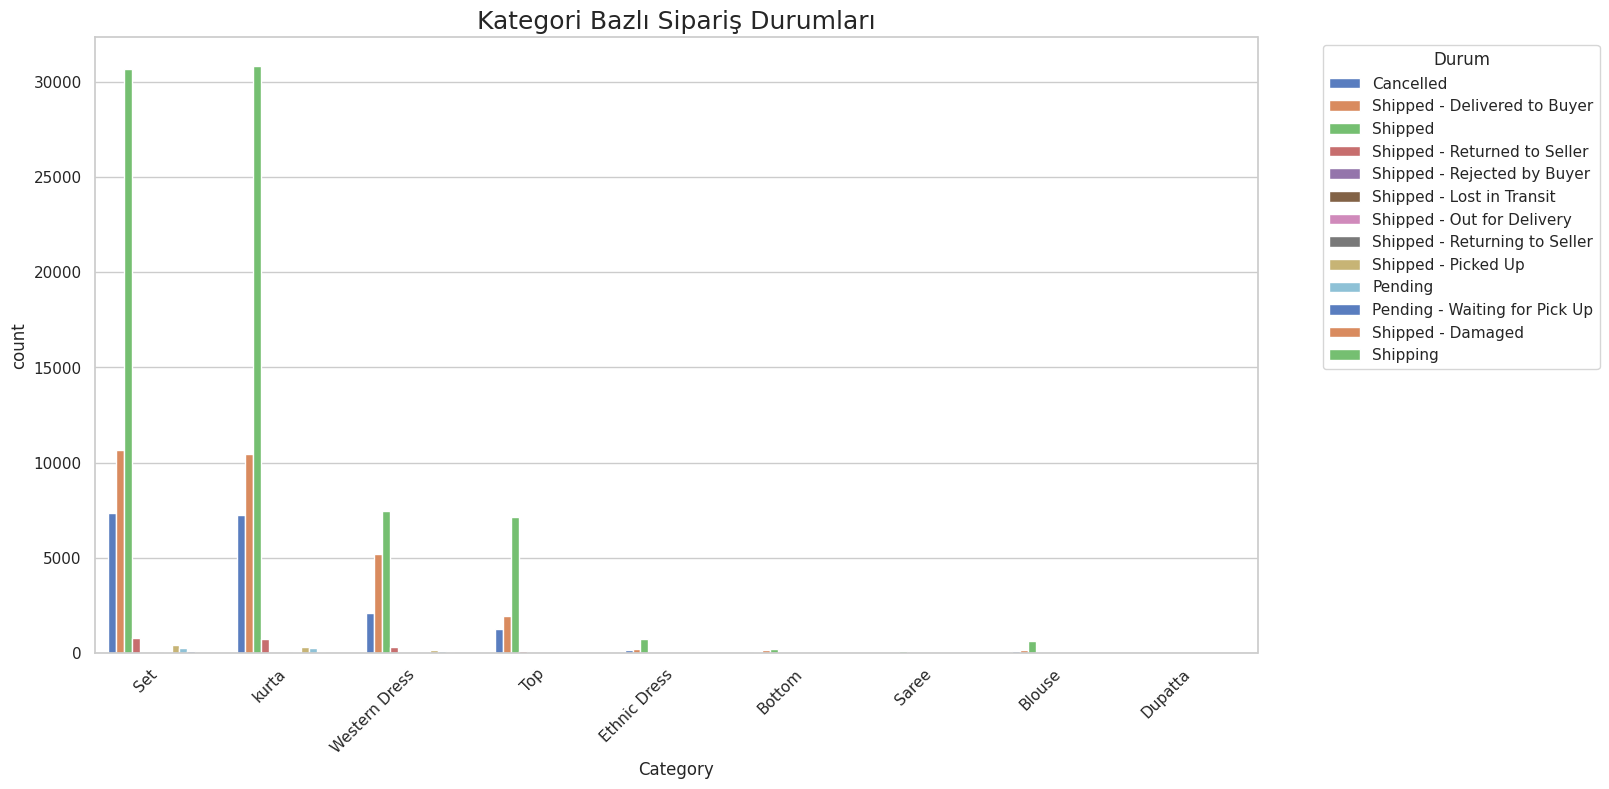

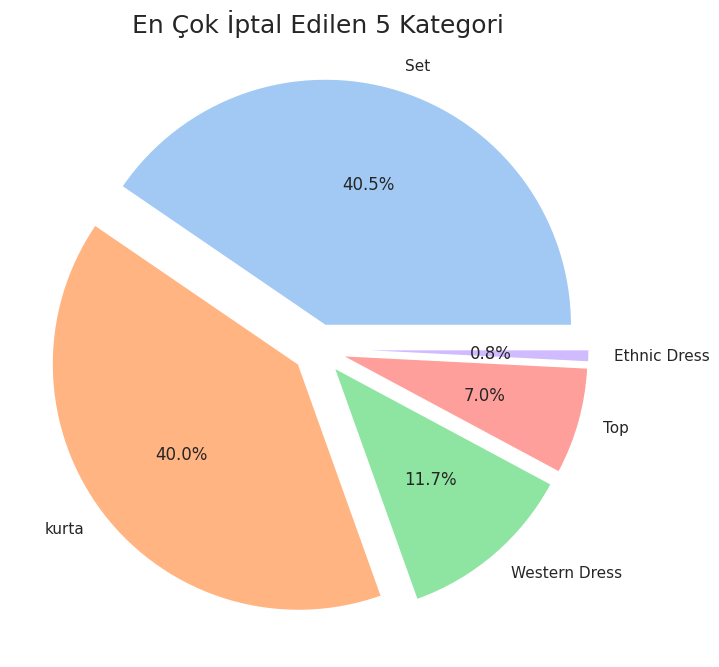

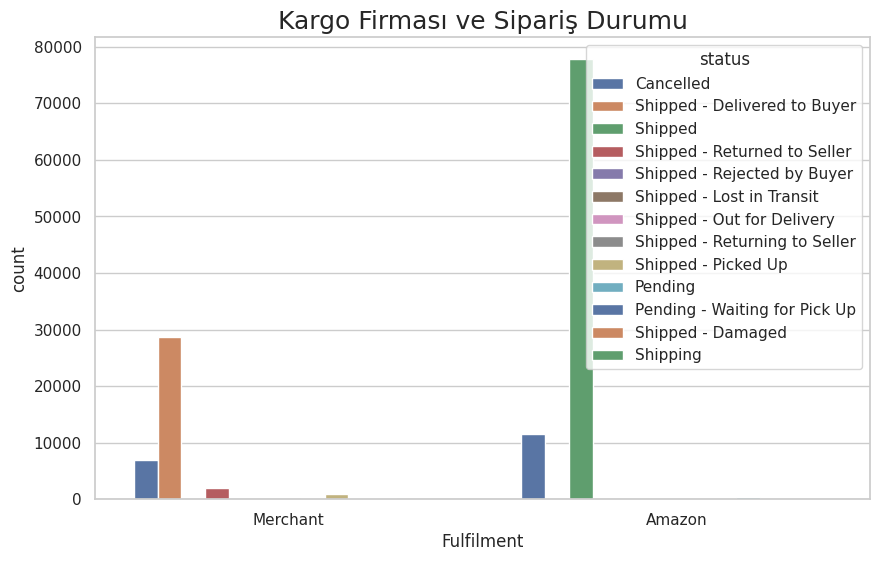

In [24]:
# 1. Kategori Bazlı Sipariş Durumu (Hangi kategoride iptal çok?)
plt.figure(figsize=(15, 8))
top_cat = df['Category'].value_counts().nlargest(10).index
df_filtered = df[df['Category'].isin(top_cat)]
sns.countplot(data=df_filtered, x='Category', hue='status', palette='muted')
plt.title('Kategori Bazlı Sipariş Durumları', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Durum', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 2. İptal Edilen Siparişlerin Kategori Dağılımı
plt.figure(figsize=(10, 8))
cancelled_orders = df[df['status'] == 'Cancelled']
cat_cancelled = cancelled_orders['Category'].value_counts().nlargest(5)
plt.pie(cat_cancelled, labels=cat_cancelled.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), explode=[0.1]*len(cat_cancelled))
plt.title('En Çok İptal Edilen 5 Kategori', fontsize=18)
plt.show()

# 3. Kargo Tipi ve Sipariş Durumu İlişkisi
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Fulfilment', hue='status', palette='deep')
plt.title('Kargo Firması ve Sipariş Durumu', fontsize=18)
plt.show()

/tmp/ipython-input-202/3110995716.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_cat_avg.index, y=df_cat_avg.values, palette='coolwarm')


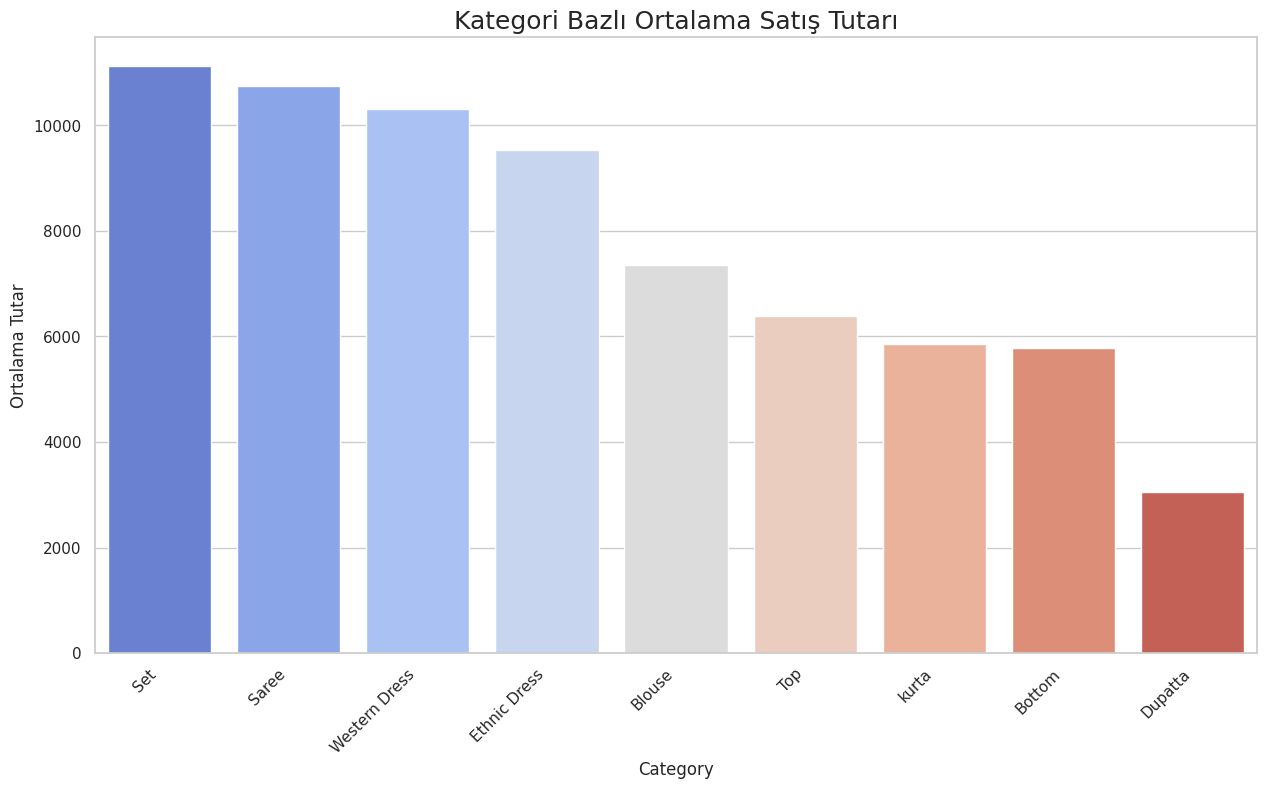

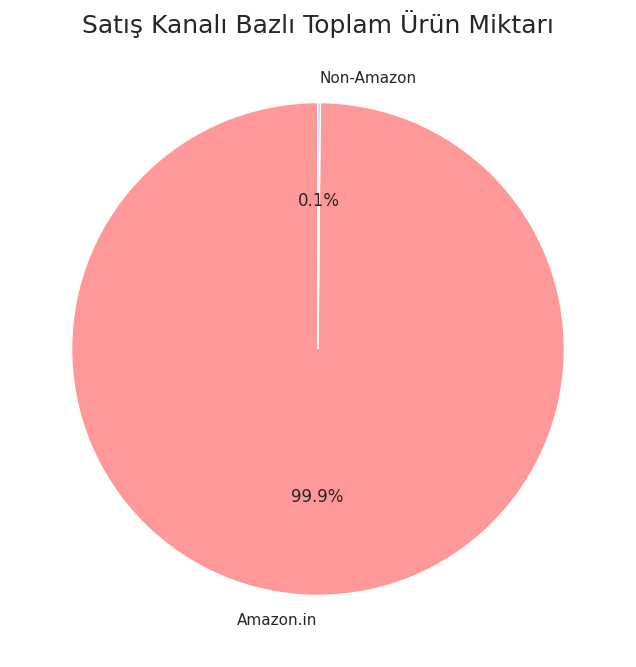

/tmp/ipython-input-202/3110995716.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Fulfilment', y='Amount', estimator=lambda x: sum(x)/len(x), palette='plasma')


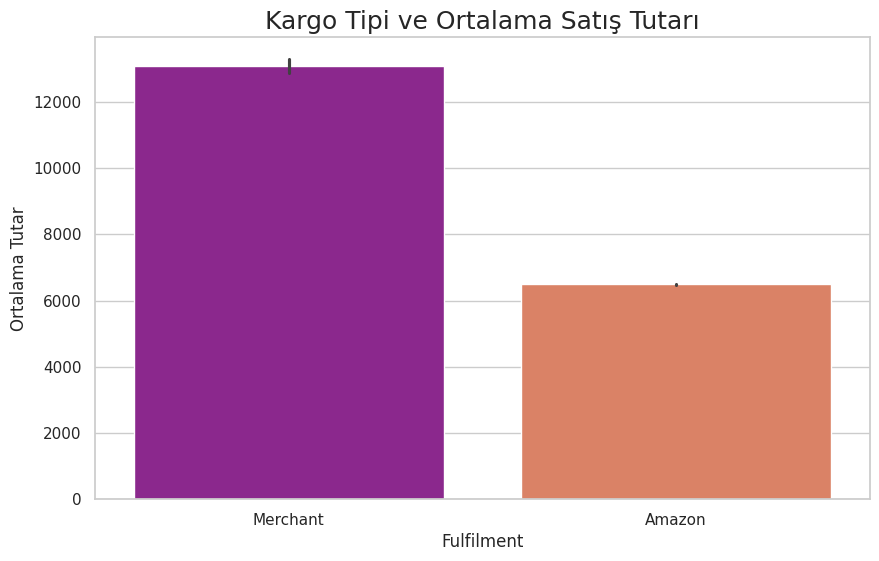

In [25]:
# 1. Kategori Bazlı Ortalama Satış Tutarı
plt.figure(figsize=(15, 8))
# En çok satan ilk 10 kategori
top_cat = df['Category'].value_counts().nlargest(10).index
df_cat_avg = df[df['Category'].isin(top_cat)].groupby('Category')['Amount'].mean().sort_values(ascending=False)

sns.barplot(x=df_cat_avg.index, y=df_cat_avg.values, palette='coolwarm')
plt.title('Kategori Bazlı Ortalama Satış Tutarı', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Ortalama Tutar')
plt.show()

# 2. Satış Kanalı Bazlı Toplam Miktar (Pasta Grafiği)
plt.figure(figsize=(8, 8))
channel_qty = df.groupby('Sales_channel')['Qty'].sum()
plt.pie(channel_qty, labels=channel_qty.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Satış Kanalı Bazlı Toplam Ürün Miktarı', fontsize=18)
plt.show()

# 3. Kargo Tipi Bazlı Ortalama Satış Tutarı
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Fulfilment', y='Amount', estimator=lambda x: sum(x)/len(x), palette='plasma')
plt.title('Kargo Tipi ve Ortalama Satış Tutarı', fontsize=18)
plt.ylabel('Ortalama Tutar')
plt.show()